# LOGISTIC REGRESSION (Econometrics Approach) - WEC 2026
## CLEANED DATA + FEATURE ENGINEERING (RATIOS + PASSES TOP THIRD)

In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    RocCurveDisplay,
)

In [13]:
# Set the data working directory
print(os.getcwd())
DATA_PATH = "/Users/teo/Library/CloudStorage/GoogleDrive-t.leprovost@student.uw.edu.pl/My Drive/Studies_UW/Warsaw_Econometrics_Challenge"
os.chdir(DATA_PATH)

/Users/teo/Library/CloudStorage/GoogleDrive-t.leprovost@student.uw.edu.pl/My Drive/Studies_UW/Warsaw_Econometrics_Challenge


In [14]:
# Set options to prevent truncation of columns in dataframe displays
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# 1. LOAD DATA

In [ ]:
quarters_1 = pd.read_csv("EDA2/features/all_engineered_features.csv")
quarters_2 = pd.read_csv("data/players_quarters_final_feature_engineered_v3.csv")

print(quarters_1.shape)
print(quarters_2.shape)

(3486, 74)
(3114, 51)


In [16]:
# Merge by intersection of rows, remove duplicate columns
quarters = quarters_1.merge(quarters_2, left_index=True, right_index=True)
quarters = quarters.loc[:, ~quarters.columns.duplicated()]

print(f"Merged shape: {quarters.shape}")
print(f"Rows in common: {len(quarters)}")

Merged shape: (3114, 125)
Rows in common: 3114


# 2. FEATURE GROUPING

In [ ]:
# Auto-detect behavioral features (last15, cumul, ratio prefixes)
behavior_features = [c for c in quarters.columns if any(c.startswith(p) for p in ["last15_", "cumul_", "ratio_"])]

# Team-level features (context, not player-dependent)
team_features = ["position", "is_home", "formation", "minute_in", "minute_out", "subbed"]

# All features combined
all_features = behavior_features + team_features

# Fill missing values in behavioral features with 0
quarters[behavior_features] = quarters[behavior_features].fillna(0)

# Target variable
TARGET = "scored_after"

print(f"Behavioral features: {len(behavior_features)}")
print(f"Team features: {len(team_features)}")
print(f"Total features: {len(all_features)}")

Behavioral features: 49
Team features: 6
Total features: 55


# 3-5. DATA PREP + PREPROCESSING + MODEL

In [ ]:
# Prepare data
df = quarters[all_features + [TARGET]].copy()
df = df.dropna(subset=[TARGET])

X = df[all_features]
y = df[TARGET].astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Class distribution:\n{y.value_counts()}")
print(f"Positive rate: {y.mean():.2%}\n")

# Feature type separation
numeric_features = behavior_features + ["minute_in", "minute_out"]
categorical_features = ["position", "formation"]
boolean_features = ["is_home", "subbed"]

# Build preprocessing + model pipeline
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ("bool", "passthrough", boolean_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", solver="lbfgs", max_iter=1000, random_state=42)),
])

# Cross-validation (5-fold stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_prob_oof = cross_val_predict(pipeline, X, y, cv=cv, method="predict_proba")[:, 1]
y_pred_oof = (y_prob_oof >= 0.5).astype(int)

# Quick evaluation
print("="*50)
print("CROSS-VALIDATION RESULTS (5-fold)")
print("="*50)
print(f"AUC-ROC: {roc_auc_score(y, y_prob_oof):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y, y_pred_oof):.4f}\n")
print(classification_report(y, y_pred_oof, target_names=["No goal", "Goal"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_oof))

Dataset shape: (3114, 55)
Class distribution:
scored_after
0    2912
1     202
Name: count, dtype: int64
Positive rate: 6.49%

CROSS-VALIDATION RESULTS (5-fold)
AUC-ROC: 0.7125
Balanced Accuracy: 0.6498

              precision    recall  f1-score   support

     No goal       0.96      0.69      0.80      2912
        Goal       0.12      0.61      0.20       202

    accuracy                           0.69      3114
   macro avg       0.54      0.65      0.50      3114
weighted avg       0.91      0.69      0.76      3114


Confusion Matrix:
[[2011  901]
 [  79  123]]


# 6. FIT & FEATURE IMPORTANCE

In [ ]:
pipeline.fit(X, y)

# Extract feature names after one-hot encoding
cat_encoder = pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
all_feat_names = numeric_features + cat_names + boolean_features

# Get coefficients
coef_df = pd.DataFrame({
    "feature": all_feat_names,
    "coef": pipeline.named_steps["classifier"].coef_[0],
}).assign(abs_coef=lambda x: x["coef"].abs()).sort_values("abs_coef", ascending=False)

print("\nTop 15 Features (by absolute coefficient):")
print(coef_df.head(15)[["feature", "coef"]].to_string(index=False))


Top 15 Features (by absolute coefficient):
                                feature      coef
                             position_D -2.339310
                        formation_4-2-4 -2.087795
                      formation_4-1-3-2 -2.027680
                        formation_5-2-3  1.289958
                      formation_4-1-4-1  1.225788
                       ratio_peak_speed -1.215029
                             position_M -1.053955
                      formation_4-2-3-1  1.029129
                        formation_4-4-2  0.947281
                            cumul_shots  0.667506
                          last15_passes -0.534592
                             minute_out  0.506959
                                 subbed  0.439848
                   ratio_mean_max_speed  0.434085
last15_passes_received_x_last15_sprints  0.411245


# 7. PLOTS

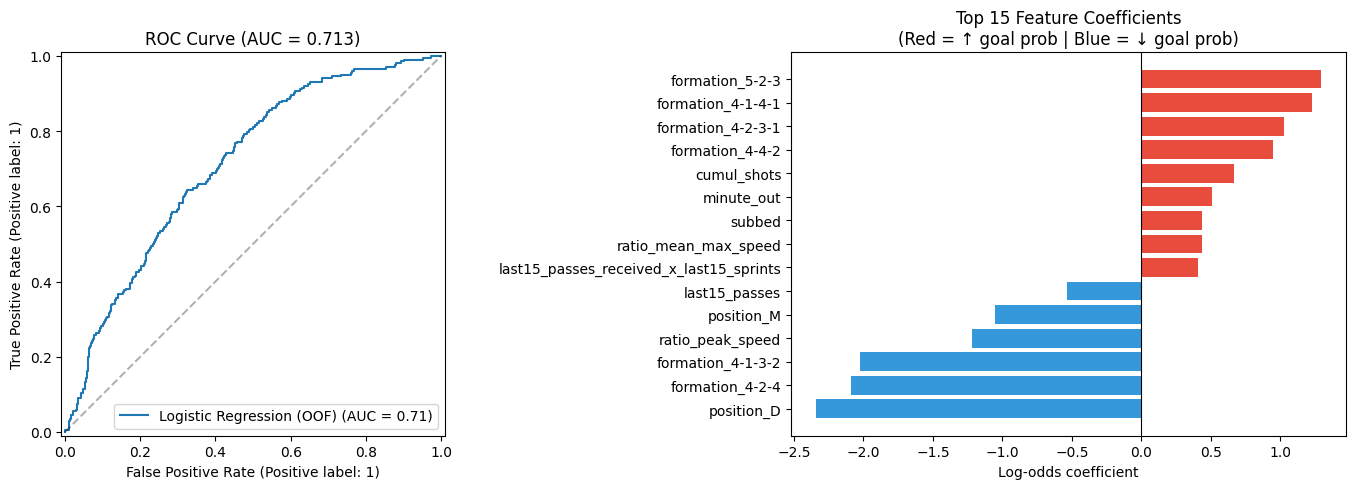

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

auc = roc_auc_score(y, y_prob_oof)

# ROC curve
RocCurveDisplay.from_predictions(y, y_prob_oof, ax=axes[0], name="Logistic Regression (OOF)")
axes[0].set_title(f"ROC Curve (AUC = {auc:.3f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].legend()

# Top 15 features
top15 = coef_df.head(15).sort_values("coef")
colors = ["#e74c3c" if c > 0 else "#3498db" for c in top15["coef"]]
axes[1].barh(top15["feature"], top15["coef"], color=colors)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Top 15 Feature Coefficients\n(Red = ↑ goal prob | Blue = ↓ goal prob)")
axes[1].set_xlabel("Log-odds coefficient")

plt.tight_layout()
plt.savefig("logistic_regression_results.png", dpi=150)
plt.show()

# 8. STATISTICAL INFERENCE (statsmodels MLE)

In [ ]:
import statsmodels.api as sm
from scipy import stats

# Preprocess data (fit preprocessor on full dataset)
X_processed = pipeline.named_steps["preprocessor"].fit_transform(X)
X_sm = sm.add_constant(X_processed)

# Fit logistic regression via MLE
model = sm.Logit(y, X_sm).fit(disp=False)

# Summary table
summary = pd.DataFrame({
    "Coef": model.params,
    "SE": model.bse,
    "z": model.tvalues,
    "p-value": model.pvalues,
    "OR": np.exp(model.params),
}).sort_values("p-value")

print("\n" + "="*70)
print("LOGISTIC REGRESSION — STATSMODELS MLE")
print("="*70)
print(summary.round(4).to_string())

print(f"\n{'='*70}")
print("MODEL FIT STATISTICS")
print(f"{'='*70}")
print(f"N observations: {int(model.nobs)}")
print(f"Log-Likelihood: {model.llf:.2f}")
print(f"AIC: {model.aic:.2f} | BIC: {model.bic:.2f}")
print(f"McFadden R²: {1 - (model.llf / model.llnull):.4f}")
print(f"LR test p-value: {model.llr_pvalue:.4e}")
print(f"\nSignificance: *** p<0.001 | ** p<0.01 | * p<0.05")


LOGISTIC REGRESSION — STATSMODELS MLE
          Coef            SE       z  p-value      OR
x52    -2.1985  2.737000e-01 -8.0314   0.0000  0.1110
x53    -1.0444  1.969000e-01 -5.3035   0.0000  0.3519
x51     0.4426  1.064000e-01  4.1579   0.0000  1.5567
const  -2.2534  5.907000e-01 -3.8147   0.0001  0.1050
x47    -0.3267  8.840000e-02 -3.6959   0.0002  0.7213
x50    -0.3348  9.300000e-02 -3.5985   0.0003  0.7155
x7     -0.3838  1.503000e-01 -2.5529   0.0107  0.6813
x63    -0.2653  1.608000e-01 -1.6495   0.0990  0.7670
x56     0.9417  5.962000e-01  1.5794   0.1142  2.5643
x17     0.2585  1.640000e-01  1.5765   0.1149  1.2950
x32     1.0032  6.928000e-01  1.4481   0.1476  2.7271
x60     0.8201  5.768000e-01  1.4219   0.1551  2.2708
x34    -0.3026  2.285000e-01 -1.3243   0.1854  0.7389
x57     0.7576  5.774000e-01  1.3122   0.1895  2.1332
x9     -0.1642  1.320000e-01 -1.2431   0.2138  0.8486
x19    -0.2425  1.962000e-01 -1.2361   0.2164  0.7847
x35    -0.7439  6.576000e-01 -1.1313   0.25